In [1]:
# =============================================================================
# Fase 1 - Análisis Exploratorio de Datos (EDA) y Preprocesamiento
# Dataset: Adult Census Income (UCI Machine Learning Repository)
# =============================================================================
# Este notebook cubre el análisis exploratorio completo del dataset Adult,
# incluyendo comprensión de los datos, preprocesamiento (valores nulos,
# dummificacion, normalizacion, outliers) y particionamiento train/test.
# Es la base sobre la cual se construyen los modelos de las Fases 2 y 3.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Configuracion general de graficas
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style("whitegrid")

print("Librerias cargadas correctamente.")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")

Librerias cargadas correctamente.
pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.9
seaborn    : 0.13.2


In [2]:
# =============================================================================
# Carga y consolidacion del dataset
# =============================================================================
# El dataset Adult viene dividido en dos archivos: adult.data (entrenamiento)
# y adult.test (prueba). Se consolidan en un unico dataframe para realizar
# el EDA y el preprocesamiento sobre el conjunto completo antes de volver
# a particionar.
# =============================================================================

# Nombres de las columnas segun la documentacion oficial de UCI
columnas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income'
]

# Carga de adult.data
# sep=', ' porque los valores estan separados por coma y espacio
df_train = pd.read_csv(
    '../datos/adult.data',
    names=columnas,
    sep=', ',
    engine='python',
    na_values='?'
)

# Carga de adult.test
# skiprows=1 para ignorar la primera linea que contiene un encabezado especial
# del validador cruzado que no es un registro de datos
df_test = pd.read_csv(
    '../datos/adult.test',
    names=columnas,
    sep=', ',
    engine='python',
    na_values='?',
    skiprows=1
)

# El archivo adult.test tiene un punto al final de cada etiqueta de income
# (ej. "<=50K." en lugar de "<=50K"), se elimina para unificar el formato
df_test['income'] = df_test['income'].str.replace('.', '', regex=False)

# Consolidacion en un unico dataframe
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Registros en adult.data : {len(df_train):,}")
print(f"Registros en adult.test : {len(df_test):,}")
print(f"Total consolidado       : {len(df):,}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nForma del dataframe: {df.shape}")

Registros en adult.data : 32,561
Registros en adult.test : 16,281
Total consolidado       : 48,842

Columnas: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Forma del dataframe: (48842, 15)


In [3]:
# =============================================================================
# Comprension inicial del dataset
# =============================================================================
# Se revisa la estructura general del dataframe: tipos de datos, primeras
# filas y estadisticas descriptivas basicas para entender con que estamos
# trabajando antes de cualquier transformacion.
# =============================================================================

print("=" * 60)
print("PRIMERAS 5 FILAS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("TIPOS DE DATOS Y VALORES NO NULOS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("ESTADISTICAS DESCRIPTIVAS - VARIABLES NUMERICAS")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("DISTRIBUCION DE LA VARIABLE OBJETIVO")
print("=" * 60)
print(df['income'].value_counts())
print(f"\nProporcion:")
print(df['income'].value_counts(normalize=True).round(3))

PRIMERAS 5 FILAS


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



TIPOS DE DATOS Y VALORES NO NULOS
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB

ESTADISTICAS DESCRIPTIVAS - VARIABLES NUMERICAS


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000



DISTRIBUCION DE LA VARIABLE OBJETIVO
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Proporcion:
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


RESUMEN DE VALORES NULOS


,Valores nulos,Porcentaje (%)
occupation,2809,5.75
workclass,2799,5.73
native_country,857,1.75


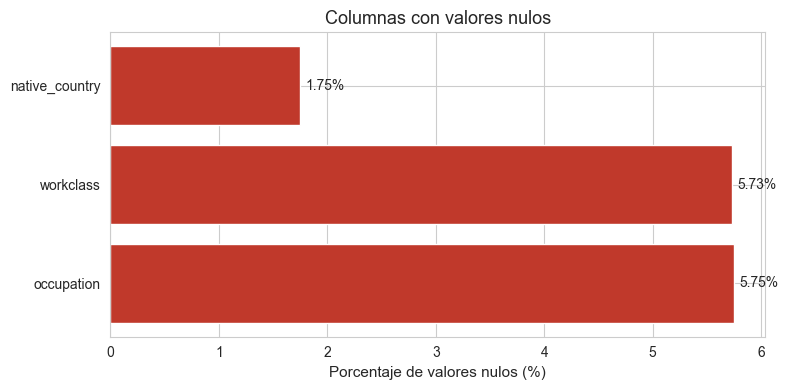


Grafica guardada.


In [4]:
# =============================================================================
# Analisis de valores nulos
# =============================================================================
# Se identifican las columnas con valores ausentes, su cantidad y porcentaje
# respecto al total de registros, para decidir la estrategia de tratamiento
# mas adecuada para cada caso.
# =============================================================================

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': nulos_pct
}).sort_values('Valores nulos', ascending=False)

print("=" * 45)
print("RESUMEN DE VALORES NULOS")
print("=" * 45)
display(resumen_nulos[resumen_nulos['Valores nulos'] > 0])

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 4))
cols_con_nulos = resumen_nulos[resumen_nulos['Valores nulos'] > 0]
ax.barh(cols_con_nulos.index, cols_con_nulos['Porcentaje (%)'], color='#c0392b')
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Columnas con valores nulos')
for i, v in enumerate(cols_con_nulos['Porcentaje (%)']):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../fase1_EDA/graficas/nulos.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafica guardada.")

In [6]:
# =============================================================================
# Tratamiento de valores nulos
# =============================================================================
# Las tres columnas con valores nulos (workclass, occupation, native_country)
# son variables categoricas con menos del 6% de ausencias. Se imputan con
# la moda de cada columna, que es la categoria mas frecuente y la estrategia
# mas apropiada para variables nominales con bajo porcentaje de nulos.
# En pandas 3.0 se usa fillna sobre el dataframe completo para evitar
# el problema de Copy-on-Write con operaciones inplace sobre columnas.
# =============================================================================

columnas_con_nulos = ['workclass', 'occupation', 'native_country']

for col in columnas_con_nulos:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f"{col:20s} -> imputado con moda: '{moda}'")

# Verificacion: no deben quedar valores nulos
nulos_restantes = df.isnull().sum().sum()
print(f"\nValores nulos restantes en el dataframe: {nulos_restantes}")

workclass            -> imputado con moda: 'Private'
occupation           -> imputado con moda: 'Prof-specialty'
native_country       -> imputado con moda: 'United-States'

Valores nulos restantes en el dataframe: 0


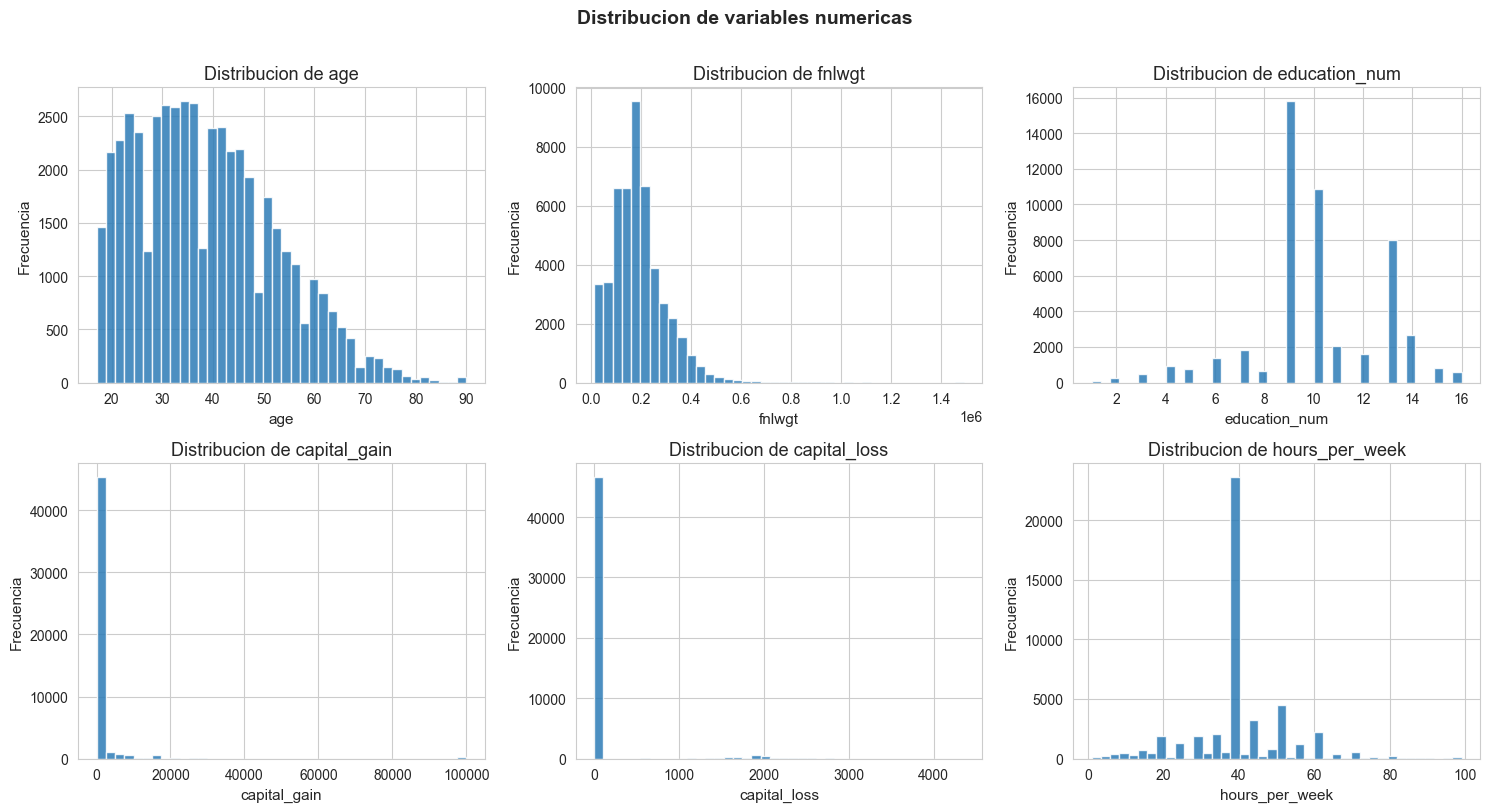

Grafica guardada.


In [7]:
# =============================================================================
# Analisis grafico - Distribucion de variables numericas
# =============================================================================
# Se visualiza la distribucion de cada variable numerica mediante histogramas
# con curva de densidad (KDE). Esto permite identificar asimetrias, rangos
# y posibles outliers antes de aplicar normalizacion.
# =============================================================================

variables_numericas = ['age', 'fnlwgt', 'education_num',
                       'capital_gain', 'capital_loss', 'hours_per_week']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].hist(df[col], bins=40, color='#2c7bb6', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribucion de variables numericas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../fase1_EDA/graficas/distribucion_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

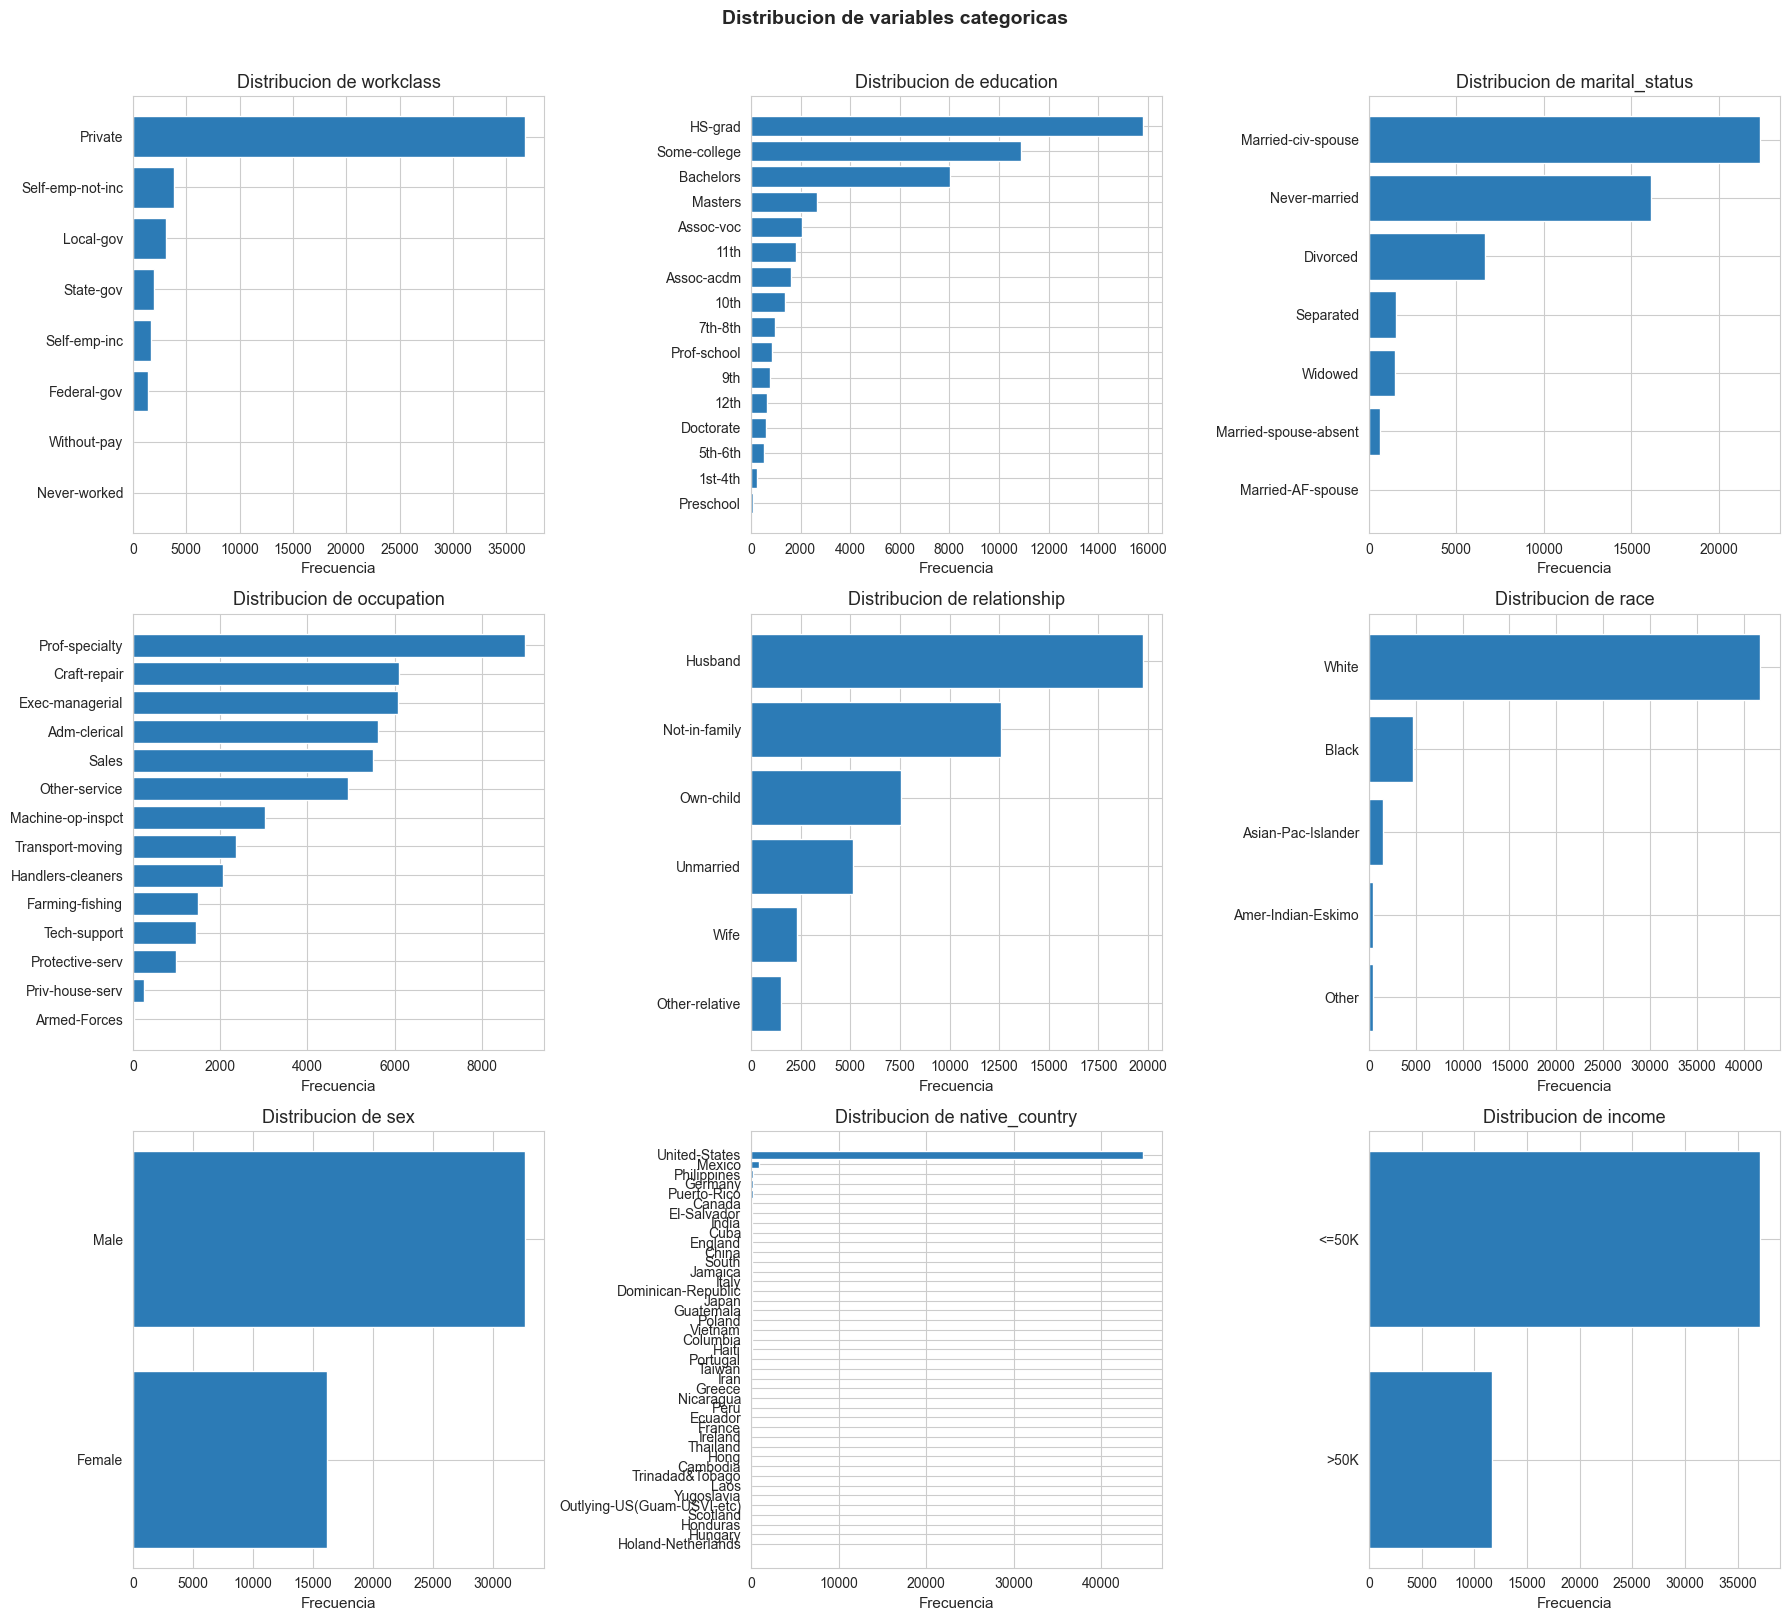

Grafica guardada.


In [8]:
# =============================================================================
# Analisis grafico - Distribucion de variables categoricas
# =============================================================================
# Se visualiza la frecuencia de cada categoria en las variables categoricas
# mediante graficas de barras horizontales. Permite identificar categorias
# dominantes, categorias poco representadas y posibles problemas de
# cardinalidad alta como en native_country.
# =============================================================================

variables_categoricas = ['workclass', 'education', 'marital_status',
                         'occupation', 'relationship', 'race',
                         'sex', 'native_country', 'income']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    conteo = df[col].value_counts()
    axes[i].barh(conteo.index, conteo.values, color='#2c7bb6', edgecolor='white')
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].set_xlabel('Frecuencia')
    axes[i].invert_yaxis()

plt.suptitle('Distribucion de variables categoricas', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../fase1_EDA/graficas/distribucion_categoricas.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

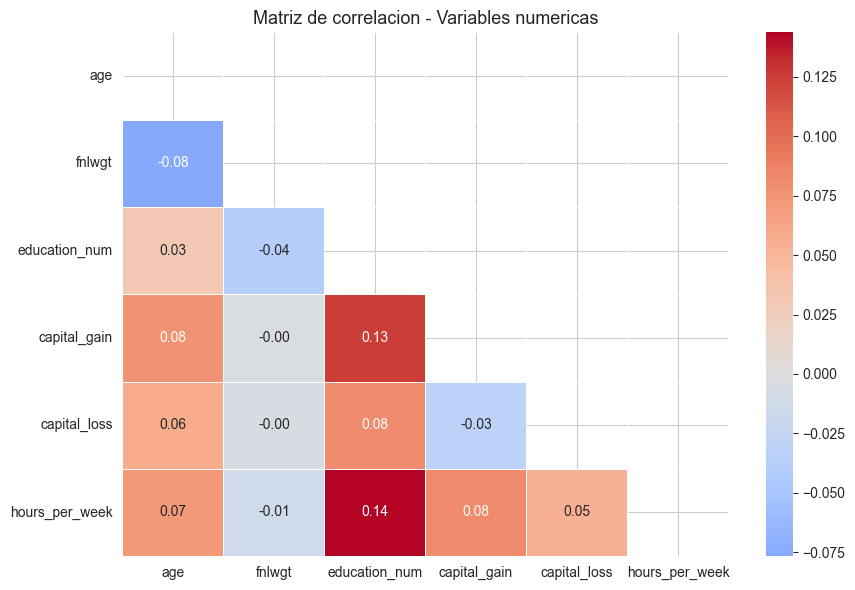

Grafica guardada.


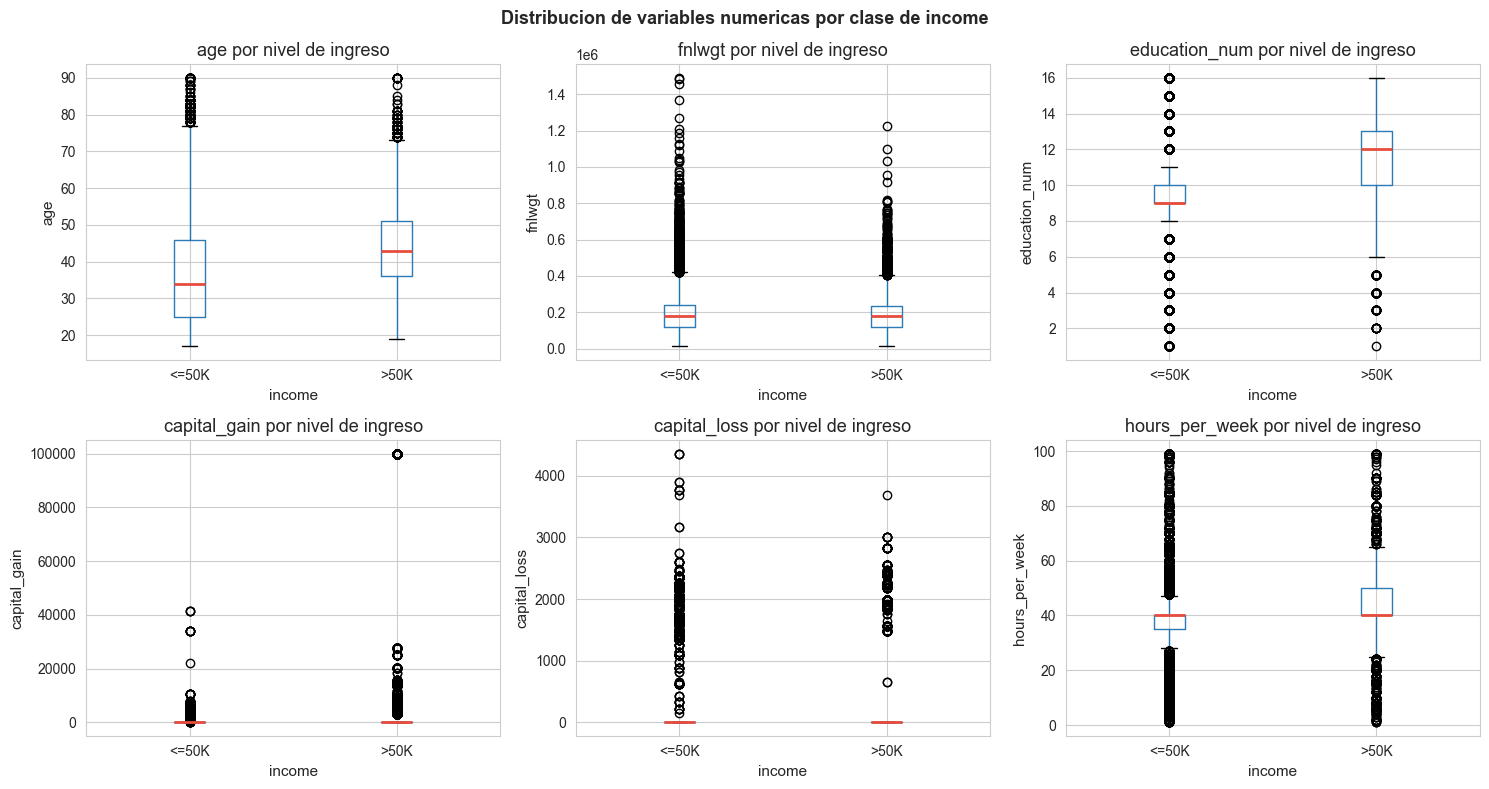

Grafica guardada.


In [9]:
# =============================================================================
# Analisis de correlacion y relacion con la variable objetivo
# =============================================================================
# Se analiza la correlacion entre variables numericas mediante un heatmap,
# y se visualiza la relacion de cada variable numerica con income mediante
# boxplots para identificar cuales variables tienen mayor poder discriminante
# entre las dos clases.
# =============================================================================

# --- Heatmap de correlacion entre variables numericas ---
fig, ax = plt.subplots(figsize=(9, 6))
correlacion = df[variables_numericas].corr()
mask = np.triu(np.ones_like(correlacion, dtype=bool))
sns.heatmap(
    correlacion,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Matriz de correlacion - Variables numericas')
plt.tight_layout()
plt.savefig('../fase1_EDA/graficas/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

# --- Boxplots por clase de income ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    df.boxplot(column=col, by='income', ax=axes[i],
               boxprops=dict(color='#2c7bb6'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(f'{col} por nivel de ingreso')
    axes[i].set_xlabel('income')
    axes[i].set_ylabel(col)

plt.suptitle('Distribucion de variables numericas por clase de income',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../fase1_EDA/graficas/boxplots_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

In [11]:
# =============================================================================
# Deteccion y manejo de outliers
# =============================================================================
# Se usa el metodo IQR (rango intercuartilico) para identificar outliers en
# cada variable numerica. Los valores que caen por debajo de Q1 - 1.5*IQR
# o por encima de Q3 + 1.5*IQR se consideran atipicos.
# Para capital_gain y capital_loss, dado que la mayoria de valores es 0 y
# los outliers tienen significado economico real, se aplica winsorization
# (se limitan al percentil 99) en lugar de eliminarlos, para conservar la
# informacion sin distorsionar la escala.
# Para el resto de variables se conservan los outliers ya que representan
# casos reales validos dentro del dominio del problema.
# =============================================================================

print("=" * 55)
print("CONTEO DE OUTLIERS POR VARIABLE (metodo IQR)")
print("=" * 55)

resumen_outliers = []

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    resumen_outliers.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Limite inferior': round(lim_inf, 2),
        'Limite superior': round(lim_sup, 2),
        'Outliers': n_outliers,
        'Porcentaje (%)': pct
    })

df_outliers = pd.DataFrame(resumen_outliers)
display(df_outliers)

# Winsorization de capital_gain y capital_loss al percentil 99
# Se limitan los valores extremos al techo del percentil 99 para reducir
# el impacto de los valores atipicos sin eliminar registros del dataset
for col in ['capital_gain', 'capital_loss']:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)
    print(f"{col}: winsorizado al percentil 99 -> techo = {p99:.0f}")

print(f"\nForma del dataframe tras tratamiento de outliers: {df.shape}")

CONTEO DE OUTLIERS POR VARIABLE (metodo IQR)


,Variable,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers,Porcentaje (%)
0,age,28.0,48.0,20.0,-2.00,78.00,216,0.44
1,fnlwgt,117550.5,237642.0,120091.5,-62586.75,417779.25,1453,2.97
2,education_num,9.0,12.0,3.0,4.50,16.50,1794,3.67
3,capital_gain,0.0,0.0,0.0,0.00,0.00,4035,8.26
4,capital_loss,0.0,0.0,0.0,0.00,0.00,2282,4.67
5,hours_per_week,40.0,45.0,5.0,32.50,52.50,13496,27.63


capital_gain: winsorizado al percentil 99 -> techo = 15024
capital_loss: winsorizado al percentil 99 -> techo = 2001

Forma del dataframe tras tratamiento de outliers: (48842, 15)


In [12]:
# =============================================================================
# Dummificacion de variables categoricas
# =============================================================================
# Se transforman las variables categoricas en variables binarias (0/1)
# mediante one-hot encoding. Se usa drop_first=True para evitar la
# multicolinealidad perfecta (trampa de variables dummy): si una variable
# categorica tiene k categorias, se crean k-1 columnas binarias ya que
# la categoria omitida queda implicitamente representada cuando todas
# las demas son 0.
# La variable objetivo (income) se codifica por separado como binaria:
# 0 para <=50K y 1 para >50K.
# =============================================================================

# Codificacion de la variable objetivo
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

print("Codificacion de income:")
print(df['income'].value_counts())
print(f"\n0 = <=50K  |  1 = >50K")

# Variables categoricas a dummificar (se excluye income que ya fue codificada)
cols_categoricas = ['workclass', 'education', 'marital_status', 'occupation',
                    'relationship', 'race', 'sex', 'native_country']

# Se conserva education_num como variable numerica equivalente a education,
# pero se dummifica education de todas formas para capturar diferencias
# cualitativas entre niveles educativos que education_num no distingue
df = pd.get_dummies(df, columns=cols_categoricas, drop_first=True)

print(f"\nForma del dataframe tras dummificacion: {df.shape}")
print(f"Numero de columnas: {df.shape[1]}")
print(f"\nPrimeras columnas: {list(df.columns[:10])}")
print(f"Ultimas columnas:  {list(df.columns[-5:])}")

Codificacion de income:
income
0    37155
1    11687
Name: count, dtype: int64

0 = <=50K  |  1 = >50K

Forma del dataframe tras dummificacion: (48842, 98)
Numero de columnas: 98

Primeras columnas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'income', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private']
Ultimas columnas:  ['native_country_Thailand', 'native_country_Trinadad&Tobago', 'native_country_United-States', 'native_country_Vietnam', 'native_country_Yugoslavia']


In [13]:
# =============================================================================
# Normalizacion de variables numericas
# =============================================================================
# Se aplica normalizacion Min-Max a las variables numericas continuas para
# escalarlas al rango [0, 1]. Esto es importante para los modelos de la
# Fase 2 (redes neuronales) que son sensibles a la escala de los datos.
# Random Forest (Fase 3) no requiere normalizacion, pero se aplica de todas
# formas para mantener un dataset unificado entre las tres fases.
# La variable income y las dummies (valores ya en 0/1) no se normalizan.
# =============================================================================

variables_a_normalizar = ['age', 'fnlwgt', 'education_num',
                          'capital_gain', 'capital_loss', 'hours_per_week']

scaler = MinMaxScaler()
df[variables_a_normalizar] = scaler.fit_transform(df[variables_a_normalizar])

print("Normalizacion Min-Max aplicada a:")
for col in variables_a_normalizar:
    print(f"  {col:20s} -> min={df[col].min():.4f}  max={df[col].max():.4f}")

print(f"\nForma del dataframe final: {df.shape}")
display(df[variables_a_normalizar].describe().round(4))

Normalizacion Min-Max aplicada a:
  age                  -> min=0.0000  max=1.0000
  fnlwgt               -> min=0.0000  max=1.0000
  education_num        -> min=0.0000  max=1.0000
  capital_gain         -> min=0.0000  max=1.0000
  capital_loss         -> min=0.0000  max=1.0000
  hours_per_week       -> min=0.0000  max=1.0000

Forma del dataframe final: (48842, 98)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.0000,48842.0000,48842.0000,48842.0000,48842.0000,48842.0000
mean,0.2965,0.1200,0.6052,0.0417,0.0421,0.4023
std,0.1878,0.0714,0.1714,0.1665,0.1922,0.1264
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.1507,0.0712,0.5333,0.0000,0.0000,0.3980
50%,0.2740,0.1122,0.6000,0.0000,0.0000,0.3980
75%,0.4247,0.1525,0.7333,0.0000,0.0000,0.4490
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Variables de entrada (X): (48842, 97)
Variable objetivo   (y): (48842,)

Conjunto de entrenamiento : 39,073 registros (80.0%)
Conjunto de prueba        : 9,769 registros  (20.0%)

Distribucion de clases en entrenamiento:
income
0    0.761
1    0.239
Name: proportion, dtype: float64

Distribucion de clases en prueba:
income
0    0.761
1    0.239
Name: proportion, dtype: float64


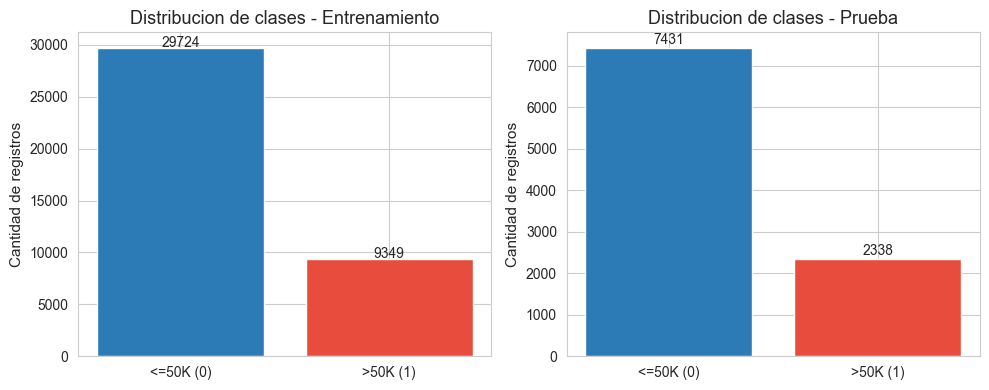

Grafica guardada.


In [14]:
# =============================================================================
# Particionamiento train/test
# =============================================================================
# Se divide el dataset en conjunto de entrenamiento (80%) y prueba (20%).
# Se elige 80/20 porque con 48,842 registros el 20% equivale a ~9,768
# muestras, suficientes para una evaluacion estadisticamente robusta,
# mientras que el 80% garantiza que los modelos tengan suficiente informacion
# para aprender patrones complejos.
# Se usa stratify=y para mantener la misma proporcion de clases (76/24)
# en ambos conjuntos, lo cual es fundamental dado el desbalance del dataset.
# random_state=42 garantiza reproducibilidad en las tres fases del proyecto.
# =============================================================================

# Separacion de variables de entrada y variable objetivo
X = df.drop(columns=['income'])
y = df['income']

print(f"Variables de entrada (X): {X.shape}")
print(f"Variable objetivo   (y): {y.shape}")

# Particionamiento estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nConjunto de entrenamiento : {X_train.shape[0]:,} registros ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Conjunto de prueba        : {X_test.shape[0]:,} registros  ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nDistribucion de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribucion de clases en prueba:")
print(y_test.value_counts(normalize=True).round(3))

# Verificacion visual del balance de clases
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nombre, serie) in zip(axes, [('Entrenamiento', y_train), ('Prueba', y_test)]):
    conteo = serie.value_counts()
    ax.bar(['<=50K (0)', '>50K (1)'], conteo.values, color=['#2c7bb6', '#e74c3c'])
    ax.set_title(f'Distribucion de clases - {nombre}')
    ax.set_ylabel('Cantidad de registros')
    for j, v in enumerate(conteo.values):
        ax.text(j, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../fase1_EDA/graficas/particionamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

In [15]:
# =============================================================================
# Guardado del dataset procesado
# =============================================================================
# Se exportan los cuatro conjuntos (X_train, X_test, y_train, y_test) como
# archivos CSV en la carpeta datos/ para que las Fases 2 y 3 los carguen
# directamente sin necesidad de repetir el preprocesamiento.
# Esto garantiza que los tres modelos se evaluen exactamente sobre los mismos
# datos con el mismo particionamiento.
# =============================================================================

X_train.to_csv('../datos/X_train.csv', index=False)
X_test.to_csv('../datos/X_test.csv', index=False)
y_train.to_csv('../datos/y_train.csv', index=False)
y_test.to_csv('../datos/y_test.csv', index=False)

print("Archivos guardados en la carpeta datos/:")
print(f"  X_train.csv -> {X_train.shape[0]:,} registros, {X_train.shape[1]} variables")
print(f"  X_test.csv  -> {X_test.shape[0]:,} registros, {X_test.shape[1]} variables")
print(f"  y_train.csv -> {y_train.shape[0]:,} registros")
print(f"  y_test.csv  -> {y_test.shape[0]:,} registros")

print("\n" + "=" * 55)
print("RESUMEN FINAL DE LA FASE 1")
print("=" * 55)
print(f"Registros totales        : {len(df):,}")
print(f"Variables de entrada     : {X.shape[1]}")
print(f"Variables originales     : 14")
print(f"Variables tras dummies   : {X.shape[1]}")
print(f"Valores nulos tratados   : workclass, occupation, native_country")
print(f"Outliers tratados        : capital_gain, capital_loss (winsorization p99)")
print(f"Normalizacion            : Min-Max en 6 variables numericas")
print(f"Particionamiento         : 80% train / 20% test (stratified)")
print(f"Desbalance de clases     : 76.1% (<=50K) / 23.9% (>50K)")
print(f"\nFase 1 completada.")

Archivos guardados en la carpeta datos/:
  X_train.csv -> 39,073 registros, 97 variables
  X_test.csv  -> 9,769 registros, 97 variables
  y_train.csv -> 39,073 registros
  y_test.csv  -> 9,769 registros

RESUMEN FINAL DE LA FASE 1
Registros totales        : 48,842
Variables de entrada     : 97
Variables originales     : 14
Variables tras dummies   : 97
Valores nulos tratados   : workclass, occupation, native_country
Outliers tratados        : capital_gain, capital_loss (winsorization p99)
Normalizacion            : Min-Max en 6 variables numericas
Particionamiento         : 80% train / 20% test (stratified)
Desbalance de clases     : 76.1% (<=50K) / 23.9% (>50K)

Fase 1 completada.
